## <font color = #0288d1>卷积模型与训练</font>

+ ### 卷积神经网络通常具有的架构是：

- ### 卷积层
- ### 激活
- ### 池化


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision.transforms import Compose, ToTensor, Normalize
from torchvision import datasets

In [2]:
mean = torch.tensor(0.1307)
std = torch.tensor(0.3081)
compose = Compose([ToTensor(), Normalize(mean,std)])
train_dataset = datasets.MNIST('./data', train=True, transform=compose, download=False)
test_dataset =  datasets.MNIST('./data', train=False, transform=compose, download=False)
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000)

In [3]:
def mini_batch_train(data_loader,model,optimizer,loss_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        # 置为训练状态
        model.train()
        # Step 1 - 前向计算预测值
        yhat = model(x_batch)
        # Step 2 - 计算损失
        mini_batch_loss = loss_fn(yhat, y_batch)
        # Step 3 - 计算梯度
        mini_batch_loss.backward()
        # Step 4 - 参数更新
        optimizer.step()
        optimizer.zero_grad()

        mini_batch_losses.append(mini_batch_loss.item())
                  
    loss = np.mean(mini_batch_losses)
    return loss

In [4]:
def mini_batch_val(data_loader,model,loss_fn):
    mini_batch_losses = []
    for x_batch, y_batch in data_loader:
        # 置为验证状态
        model.eval()
        # Step 1 - 前向计算预测值
        yhat = model(x_batch)
        # Step 2 - 计算损失
        mini_batch_loss = loss_fn(yhat, y_batch)
        mini_batch_losses.append(mini_batch_loss.item())
                  
    loss = np.mean(mini_batch_losses)
    return loss

In [5]:
def train(model, train_loader, test_loader, loss_fn, optimizer, epochs):
    # 指定随机数种子，可以再现数据
    np.random.seed(23)
    torch.manual_seed(23)

    # 循环轮数计数
    total_epochs = 0

    losses = []  # 每轮训练的损失
    val_losses = [] #  每轮验证数据的损失

    for epoch in range(epochs):
        model.train()
        total_epochs += 1

        # 进入mini-batch的内循环
        loss = mini_batch_train(train_loader,model,optimizer,loss_fn)
        losses.append(loss)

        # 验证数据集（验证不需要计算梯度）
        with torch.no_grad():
            # 验证集的 mini_batch
            val_loss = mini_batch_val(test_loader,model,loss_fn)
            val_losses.append(val_loss)
    
    return losses, val_losses

In [6]:
class CNN(nn.Module):
    def __init__(self, n_feature, p=0.0):
        super().__init__()
        self.n_feature = n_feature
        self.p = p
        # Creates the convolution layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_feature, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=n_feature, out_channels=n_feature, kernel_size=3,padding=1)
        
        self.fc1 = nn.Linear(n_feature*7*7, 392)
        self.fc2 = nn.Linear(392, 196)
        self.fc3 = nn.Linear(196, 98)
        self.fc4 = nn.Linear(98, 10)
        # Creates dropout layers
        self.drop = nn.Dropout(self.p)

    def featurizer(self, x):
        # Featurizer
        # First convolutional block
        # 1@28x28 -> n_feature@28x28 -> n_feature@14x14
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
        # Second convolutional block
        # n_feature@14x14 -> n_feature@14x14 -> n_feature@7x7
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, kernel_size=2)
       
        x = nn.Flatten()(x)
        return x

    def classifier(self, x):
        
        if self.p > 0:
            x = self.drop(x)
        x = self.fc1(x)
        x = F.relu(x)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc2(x)
        x = F.relu(x)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc3(x)
        x = F.relu(x)
        if self.p > 0:
            x = self.drop(x)
        x = self.fc4(x)
        return x

    def forward(self, x):
        x = self.featurizer(x)
        x = self.classifier(x)
        return x

In [7]:
model = CNN(16, 0.3)
lr = 3e-4
epochs = 50
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
train_loss, val_loss = train(model, train_loader, test_loader, loss_fn, optimizer, epochs)

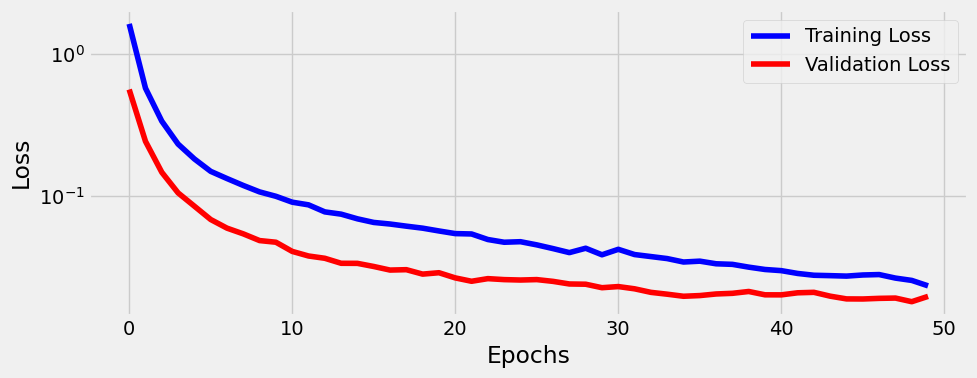

In [8]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('fivethirtyeight')
def plot_losses():
    fig = plt.figure(figsize=(10, 4))
    plt.plot(train_loss, label='Training Loss', c='b')
    plt.plot(val_loss, label='Validation Loss', c='r')
    plt.yscale('log')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    return fig

fig=plot_losses()

In [9]:
import torchmetrics
accuracy = torchmetrics.Accuracy(task='multiclass', num_classes=10)
for _, (x, y) in enumerate(test_loader):
    yhat = model(x)
    accuracy(yhat, y)
accuracy.compute()
print(f"Test Accuracy: {accuracy.compute().item() * 100:.2f}%")

Test Accuracy: 99.38%
